In [ ]:
from __future__ import annotations
from pathlib import Path
import dataretrieval.nwis as nwis
import dataretrieval.waterdata as waterdata
import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynhd as nhd
from pynhd import NLDI, WaterData
import pygeohydro as gh
import xarray as xr
import os
from scripts import maps, files, catchment


In [2]:
#Initialize names and parameters

nldi = NLDI()
station = '09114500' #GUNNISON RIVER above blue mesa reservoir
WY = 2025 #2025 water year ends on oct 1 2025, so the DOI falles within this water year

basin = nldi.get_basins(station)
basinname = 'BlueMesaReservoir'
geometry = basin.geometry.iloc[0]
watershed = "Upper Gunnison"
AOI = 'Above Blue Mesa Reservoir'
DOI = '04-01'

## Make data files

This next code blocks will create the basic file framework for the rest of the project. It utilizes open resources such as USGS to obtain the data frames. 

In [12]:
#Basin File
site_feature, upstream_network = files.basinFile(basin, basinname, station)

done


In [3]:
#SNOTEL File
snotel = files.snotelFile(geometry,'CO')

Start retrieving data for Butte, 380_CO_SNTL 
 https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/380:CO:SNTL%7Cid=%22%22%7Cname/1979-10-01,2026-03-31/WTEQ::value?fitToScreen=false
Start retrieving data for Park Cone, 680_CO_SNTL 
 https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/680:CO:SNTL%7Cid=%22%22%7Cname/1979-10-01,2026-03-31/WTEQ::value?fitToScreen=false
Start retrieving data for Upper Taylor, 1141_CO_SNTL 
 https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/1141:CO:SNTL%7Cid=%22%22%7Cname/2009-08-26,2026-03-31/WTEQ::value?fitToScreen=false


In [14]:
#Streamflow File
discharge = files.dischargeFile(station)

Retrieving data for Site: 09114500 from 1980-01-01 to 2025-10-01...


# 1. Area of Interest

### Watershed Map with stream gauge and SNOTEL icons 

This map creates an interactive view of where the stream gauge and SNOTEL stations are in respect to the larger basin. A static image was also included due to notebook "trust" errors. 

In [15]:
maps.snotel_mapping(snotel, basin, site_feature)

Static Image Below: 

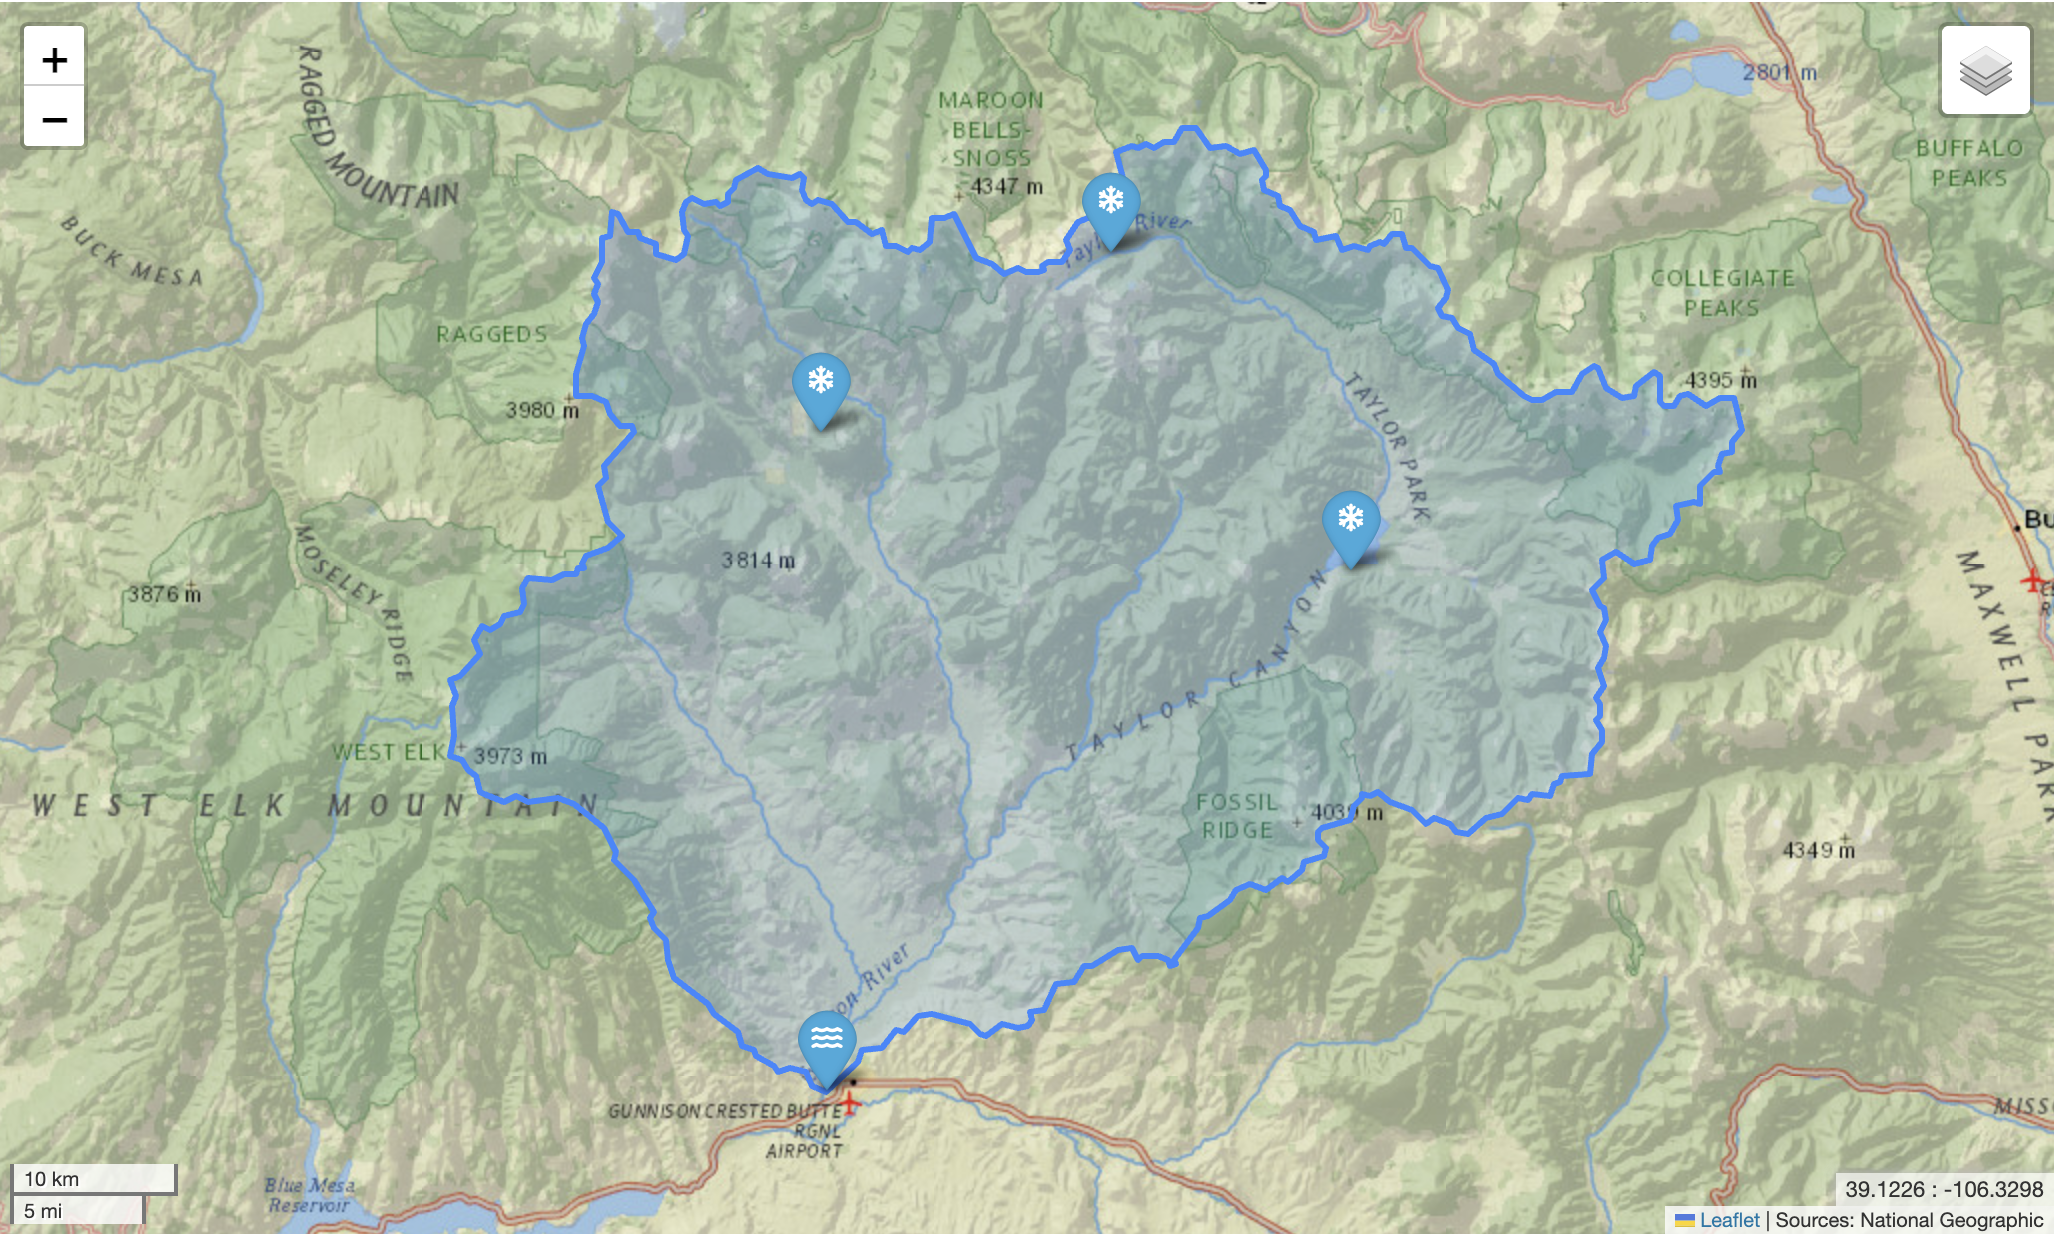

### Catchment Characteristics

The next code block will uptain basic catchment characteristics. The basin geometry, main flow lines, and minor tributarues are included in this block, as well as a few other key information pieces. The main goal of this is to demostrate The importance of the gauge in the basin, as well as give an idea of where the water mass balace is coming from. 

In [16]:
#Get information for Figures/future Dataframes

#Flowlines for the mainstem of the station
flw_main = catchment.nldi_info(station,"upstreamMain",'flowlines')

#Flowlines for the Tributaries of the station
flw_trib = catchment.nldi_info(station,'upstreamTributaries','flowlines')

#Get the stations for the upstream of the station within 1000 km
st_all = catchment.nldi_info(station,'upstreamTributaries','nwissite')

#List of active station ids 
st_active = catchment.active(st_all)

#Flow points where HUC12 boundaries intersect with the flowlines for the tributaries of the station
pp = catchment.nldi_info(station,'upstreamTributaries','huc12pp')


/opt/homebrew/Caskroom/miniforge/base/envs/hyriver/lib/python3.10/site-packages/dataretrieval/nwis.py:692: UserWarning: WARNING: Starting in March 2024, the NWIS qw data endpoint is retiring and no longer receives updates. For more information, refer to https://waterdata.usgs.gov.nwis/qwdata and https://doi-usgs.github.io/dataRetrieval/articles/Status.html or email CompTools@usgs.gov.
  warnings.warn(


The next block will produce a slope field map of the tributaries. These are generalized slope lines, which should give us information about direction of flow between main and tributary lines. It also gives us a good baseline for physical factors on streamflow, though this is very generalized so key features (like waterfalls) could be skipped over. 

As you can see from this map, our gauge station is in a relatively flat area, as there doesn't seem to be any locations with significant slope >0.4 m/m. Therefore, this means the future SWE analysis plays a larger factor on flow rate, as there likely isn't any large features that are sensitive to change (waterfalls) that could make our data extra noisy. 

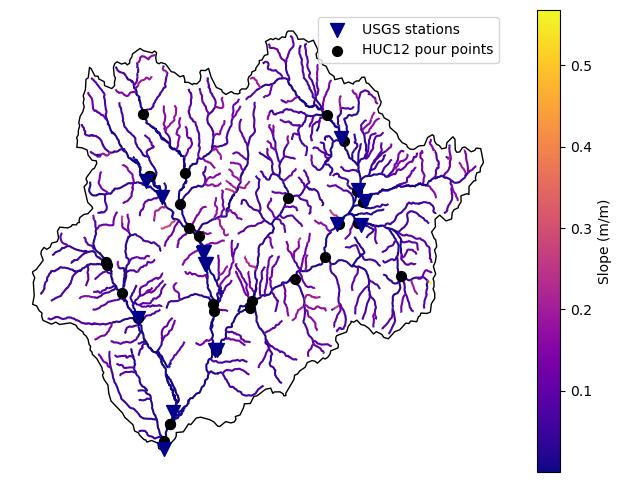

In [17]:
#Slope
slope = catchment.slope(flw_trib)

#Plot the slope attribute for the flowlines of the tributaries of the station
ax = basin.plot(facecolor="none", edgecolor="k", figsize=(8, 6))
slope.plot(
    ax=ax,  
    column="slope",
    cmap="plasma",
    legend=True,
    legend_kwds={"label": "Slope (m/m)"},
)

st_active.plot(
    ax=ax,
    label="USGS stations",
    marker="v",
    markersize=100,
    zorder=5,
    color="darkblue",
)
pp.plot(ax=ax, label="HUC12 pour points", marker="o", markersize=50, color="k", zorder=3)

ax.legend(loc="best")
ax.set_aspect("auto")
ax.set_axis_off()
ax.figure.set_dpi(100)

ax.set_axis_off()

fig = ax.get_figure()
fig.savefig("figures/slope_attrib.png", bbox_inches="tight", facecolor="w")

This next codeblock shows elevation with slope, attempting to provide more context for the slope lines seen before. 

Notice that the map still shows a relatively flat slope, even when averaging elevation. It should also be noted that the elevation seems to be relatively lower, with the lowest elevation in the bottom left. Since this is where our stream gauge is, we can assume it is measuring the collection of upstream elevation factors before entering the reservoir. 

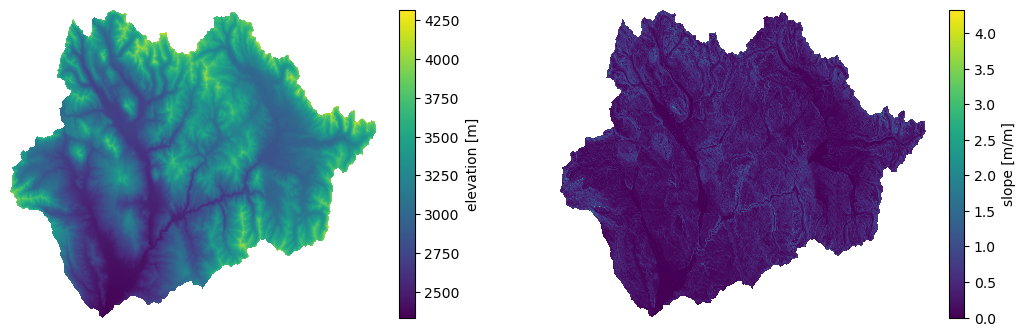

In [18]:
#Topography

topo = catchment.DEM(geometry,station)

fig, axs = plt.subplots(ncols=2, figsize=(13, 4))
topo['elevation'].plot(ax=axs[0])
topo['slope'].plot(ax=axs[1])
for ax in axs:
    ax.set_title("")
    ax.set_axis_off()
fig.savefig("Figures/dem_slope.png", bbox_inches="tight", facecolor="w")

### Land Cover

This next block is just a temporary datafram for us to work with, it does not get reported in the final result.

In [19]:
#Initial basin dataframe (elevation,slope,area)
temp_info = catchment.basin_dataframe(topo,geometry,basinname,basin,station)

The next block is creating dataframes to give us an idea of land cover. It should be noted that the most recent year available was 2021, so the land cover may be drastically different now. However, for the sake of the overall discussion, we will assume that this is sufficient.

In [20]:
#List of data years after I had an error, so most recent info is 2021
# cover: 2021, 2019, 2016, 2013, 2011, 2008, 2006, 2004, 2001
# canopy: 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021
# descriptor: 2021, 2019, 2016, 2013, 2011, 2008, 2006, 2004, 2001

descript = gh.nlcd_bygeom(basin.geometry, 100, years={"descriptor": 2021}, ssl=False)
lulcover = gh.nlcd_bygeom(basin.geometry, 100, years={"cover": [2019, 2021]}, ssl=False)

stats = gh.cover_statistics(lulcover[f"USGS-{station}"].cover_2021) # Get the land cover statistics 
roughness = gh.overland_roughness(lulcover[f"USGS-{station}"].cover_2021) # Get the overland flow roughness


The next block creates a map for the land types/keys. This will be sued to pixelate the basin and get an idea of what the land cover is. The types possible are included below, but based upon previous visuals I would expect that there are not large forests due to elevation and slope restricitons. 

In [21]:
#Create map for Land Cover
cmap, norm, levels = gh.plot.cover_legends()
cover = lulcover[f"USGS-{station}"].cover_2021 
unique = np.unique(cover.values)

nlcd_legend = {
    11: "Open Water",
    12: "Perennial Ice/Snow",
    21: "Developed, Open Space",
    22: "Developed, Low Intensity",
    23: "Developed, Medium Intensity",
    24: "Developed, High Intensity",
    31: "Barren Land (Rock/Sand/Clay)",
    41: "Deciduous Forest",
    42: "Evergreen Forest",
    43: "Mixed Forest",
    52: "Shrub/Scrub",
    71: "Grassland/Herbaceous",
    90: "Woody Wetlands",
    95: "Emergent Herbaceous Wetlands",
    127: "No Data / Masked"
}

unique = [nlcd_legend.get(code, "Unknown") for code in unique]

The next block is applying percent weigths to these classes based upon the land cover dataframes we generated earlier. This is what we will apply to our map. 

In [22]:
def map_names(val):
    return nlcd_legend.get(val, "Unknown")

v_map_names = np.vectorize(map_names) 
cover_names = xr.apply_ufunc(v_map_names, cover)
vals, counts = np.unique(cover.values, return_counts=True)

# Summary DataFrame
summary = pd.DataFrame({
    "code": vals,
    "count": counts,
    "name": [nlcd_legend.get(v, "Unknown") for v in vals]
})

# Calculate Percentage
total_pixels = summary[summary['code'] != 127]['count'].sum()
summary['percent'] = (summary['count'] / total_pixels) * 100
summary = summary[summary['code'] != 127]

lulcover = summary.copy()
lulcover = lulcover.drop(columns=["count", "code"])
lulcover.head()

lulcover.rename(columns={"name": "Basin_Name", 'percent': temp_info['Basin_Name'].values[0]}, inplace=True)
lulcover.set_index("Basin_Name", inplace=True)

lulcover = lulcover.T
lulcover.columns = lulcover.columns.str.replace(" ", "_").str.replace("(", "").str.replace(")", "").str.replace("/", "_")

#Combine into final summary
temp_info.set_index('Basin_Name', inplace=True)
basin_info = pd.concat([temp_info, lulcover], axis=1)

OutputFolder = 'files/basin_info'
if not os.path.exists(OutputFolder):
    os.makedirs(OutputFolder)
basin_info.to_csv(f'{OutputFolder}/basin_info_{station}.csv')

The map for land cover is generated below. The land use and roughness are separated, but clearly show some common trends for this catchement. First, the land use that is drier and rougher are clearly rougher as well, which is to be expected. However, this is most prevalent at the base of the catchment, where the stream gauge is. Clearly, the vegetation in this catchment actually favors the tributaries and higher elevation. However, as we know, the lower stream gauge is still serving as inlet to the reservoir below it, clearly indicating that 2021 probably had low flow years. 

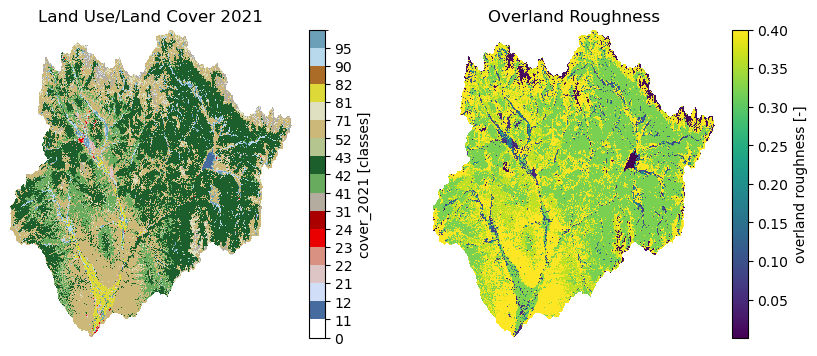

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
cover.where(cover < 127).plot(ax=ax1, cmap=cmap, levels=levels, cbar_kwargs={"ticks": levels[:-1]})
ax1.set_title("Land Use/Land Cover 2021")
ax1.set_axis_off()

roughness.plot(ax=ax2)
ax2.set_title("Overland Roughness")
ax2.set_axis_off()
fig.savefig(Path("Figures", "lulc.png"), bbox_inches="tight", facecolor="w")

### Catchment Summary 

The following will generate a summary of catchment characteristics. Some highlights are: Average Elevation: 3111.5 m (Range 2333.8 - 4320.2 m)
Average slope = 0.3 m/m
Area: 4318.1 km^2
Vegetation cover: Highest with evergreen forest and shrub
Highest Developed: open space as 0.66 or 66%

In [24]:
basin_info.T

,BlueMesaReservoir
station_id,09114500
Average_Elevation_m,3111.5432
Minimum_Elevation_m,2333.7517
Maximum_Elevation_m,4320.204
Average_Slope,0.29461083
Area_km2,4318.068667
Open_Water,0.328748
Perennial_Ice_Snow,0.262315
"Developed,_Open_Space",0.663189
"Developed,_Low_Intensity",0.218659
